In [35]:
import os
import getpass
from crewai import LLM
import duckdb
import pandas as pd

## CONFIGURING API KEYS AND LLM

In [36]:
# Cell 2: Connect to local Ollama (qwen2.5-coder:14b)
from crewai import LLM

llm = LLM(
    model="ollama/qwen2.5-coder:14b",
    base_url="http://localhost:11434"
)

print("✅ Connected to local qwen2.5-coder:14b!")

✅ Connected to local qwen2.5-coder:14b!


## CREATE SAMPLE DATASET AND LOAD INTO DUCKDB

In [37]:
sample_data = {
    "order_id": [f"ORD-{1000+i}" for i in range(1, 11)],
    "order_date": ["2024-01-05", "2024-01-07", "2024-01-12", "2024-01-15", "2024-01-20", 
                   "2024-02-02", "2024-02-08", "2024-02-14", "2024-03-01", "2024-03-06"],
    "region": ["North", "West", "East", "South", "North", "West", "North", "South", "North", "South"],
    "category": ["Electronics", "Technology", "Furniture", "Office Supplies", "Technology", 
                 "Electronics", "Technology", "Office Supplies", "Furniture", "Technology"],
    "sub_category": ["Phones", "Laptops", "Chairs", "Storage", "Accessories", 
                    "Phones", "Monitors", "Paper", "Bookcases", "Laptops"],
    "sales": [899.99, 1450.00, 249.50, 89.00, 199.99, 299.99, 480.00, 45.00, 320.00, 2200.00],
    "discount": [0.05, 0.10, 0.15, 0.00, 0.00, 0.05, 0.10, 0.00, 0.15, 0.08],
    "profit": [180.50, 320.00, 45.00, 22.50, 60.00, 50.00, 95.00, 15.00, 35.00, 490.00]
}

In [38]:
df_sample = pd.DataFrame(sample_data)

In [39]:
con = duckdb.connect(database=":memory:")
con.register("temp_df", df_sample)
con.execute("CREATE OR REPLACE TABLE dataset AS SELECT * FROM temp_df")
con.unregister("temp_df")

In [40]:
print("DuckDB Table Schema: ")
print(con.execute("DESCRIBE dataset").df())

DuckDB Table Schema: 
    column_name column_type null   key default extra
0      order_id     VARCHAR  YES  None    None  None
1    order_date     VARCHAR  YES  None    None  None
2        region     VARCHAR  YES  None    None  None
3      category     VARCHAR  YES  None    None  None
4  sub_category     VARCHAR  YES  None    None  None
5         sales      DOUBLE  YES  None    None  None
6      discount      DOUBLE  YES  None    None  None
7        profit      DOUBLE  YES  None    None  None


In [41]:
print("\nFirst 3 rows: ")
display(con.execute("SELECT * FROM dataset LIMIT 3").df())


First 3 rows: 


,order_id,order_date,region,category,sub_category,sales,discount,profit
0,ORD-1001,2024-01-05,North,Electronics,Phones,899.99,0.05,180.5
1,ORD-1002,2024-01-07,West,Technology,Laptops,1450.00,0.10,320.0
2,ORD-1003,2024-01-12,East,Furniture,Chairs,249.50,0.15,45.0


## BUILD CUSTOM CREWAI TOOLS FOR DUCKDB

In [42]:
# Cell 4: Custom DuckDB tools for the agents
from typing import Type
from pydantic import BaseModel, Field
from crewai.tools import BaseTool

class SQLQueryInput(BaseModel):
    query: str = Field(..., description="The SQL query to run on the 'dataset' table.")

class DuckDBQueryTool(BaseTool):
    name: str = "Execute DuckDB SQL Query"
    description: str = "Executes a SQL query on the 'dataset' table in DuckDB and returns markdown results."
    args_schema: Type[BaseModel] = SQLQueryInput

    def _run(self, query: str) -> str:
        # Clean query
        q = query.replace("```sql", "").replace("```", "").strip()
        try:
            result_df = con.execute(q).df()
            if result_df.empty:
                return "Query executed successfully: 0 rows returned."
            return f"Query Results ({len(result_df)} rows):\n\n" + result_df.to_markdown(index=False)
        except Exception as e:
            return f"SQL Error: {str(e)}. Please correct your query syntax."

class DuckDBSchemaTool(BaseTool):
    name: str = "Inspect DuckDB Schema"
    description: str = "Returns column names, types, and sample data of table 'dataset'."

    def _run(self) -> str:
        schema = con.execute("DESCRIBE dataset").df()
        sample = con.execute("SELECT * FROM dataset LIMIT 2").df()
        return f"Columns & Types:\n{schema.to_markdown(index=False)}\n\nSample Data:\n{sample.to_markdown(index=False)}"

query_tool = DuckDBQueryTool()
schema_tool = DuckDBSchemaTool()
print("✅ Tools ready!")

✅ Tools ready!


## Define Crew Ai agents and Tasks

In [43]:
from crewai import Agent, Crew, Process, Task

#Data Explorer
explorer = Agent(
    role="Data Explorer",
    goal="Inspect schema and column types for table 'dataset' to guide query construction.",
    backstory="Data engineer who ensures accurate column names and data types are used.",
    tools=[schema_tool, query_tool],
    llm=llm,
    verbose=True
)

#SQL Analyst
sql_analyst = Agent(
    role="DuckDB SQL Analyst",
    goal="Write and execute accurate DuckDB SQL for the user's business question.",
    backstory="Master SQL developer who writes optimal DuckDB queries and verifies output.",
    tools=[query_tool, schema_tool],
    llm=llm,
    verbose=True
)

#Data Analyst
data_analyst = Agent(
    role="Quantitative Data Analyst",
    goal="Interpret SQL query results, uncover trends, outliers, growth, and correlations.",
    backstory="Business intelligence analyst who derives strategic meaning from numbers.",
    tools=[query_tool],
    llm=llm,
    verbose=True
)

#Report & Visualization Agent
report_agent = Agent(
    role="Executive BI & Visualization Specialist",
    goal="Synthesize insights into an executive brief and produce a Plotly chart spec JSON.",
    backstory="Executive storyteller who formats concise reports and specifies chart configurations.",
    llm=llm,
    verbose=True
)
print("✅ Agents configured!")

✅ Agents configured!


In [44]:
# Cell 6: Define your analytical question and execute asynchronously!
USER_QUESTION = "What are the top categories by total profit? Include total sales and average discount rate."

task1 = Task(
    description=f"Inspect 'dataset' for question: '{USER_QUESTION}'. Identify relevant columns.",
    expected_output="Schema overview with relevant columns and types.",
    agent=explorer
)

task2 = Task(
    description=f"Write and execute DuckDB SQL for: '{USER_QUESTION}' on table 'dataset'.",
    expected_output="Executed SQL enclosed in ```sql ... ``` and markdown result table.",
    agent=sql_analyst
)

task3 = Task(
    description=f"Analyze the SQL results for: '{USER_QUESTION}'. Highlight key drivers and percentages.",
    expected_output="Detailed analytical findings, profit comparisons, and anomalies.",
    agent=data_analyst
)

task4 = Task(
    description=(
        f"Create executive report for '{USER_QUESTION}'. Include:\n"
        "1. Executive Summary\n"
        "2. Exact SQL Query in ```sql ... ```\n"
        "3. Key Analytical Insights\n"
        "4. Strategic Recommendations\n"
        "5. Plotly chart config in ```chart_spec\n"
        "{\"chart_type\": \"bar\", \"title\": \"...\", \"x_col\": \"category\", \"y_col\": \"total_profit\"}\n```"
    ),
    expected_output="Structured markdown report containing SQL, insights, and chart_spec block.",
    agent=report_agent
)

crew = Crew(
    agents=[explorer, sql_analyst, data_analyst, report_agent],
    tasks=[task1, task2, task3, task4],
    process=Process.sequential,
    verbose=True
)

print(f"🚀 Running DataCrew for question: '{USER_QUESTION}'...\n")

# Use kickoff_async with await in Jupyter
result = await crew.kickoff_async()

🚀 Running DataCrew for question: 'What are the top categories by total profit? Include total sales and average discount rate.'...



╭──────────────────────────────────────────── ✨ Update Available ✨ ─────────────────────────────────────────────╮
│                                                                                                                 │
│  A new version of CrewAI is available!                                                                          │
│                                                                                                                 │
│  Current version: 1.15.6                                                                                        │
│  Latest version:  1.15.22                                                                                       │
│                                                                                                                 │
│  To update, run: uv sync --upgrade-package crewai                                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 7184d6c5-a524-4f27-9904-2b12aa277f80                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Inspect 'dataset' for question: 'What are the top categories by total profit? Include total sales and    │
│  average discount rate.'. Identify relevant columns.                                                            │
│  ID: 95dfe8d2-c9a6-4dfd-9075-b7cef75a2088                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Data Explorer                                                                                           │
│                                                                                                                 │
│  Task: Inspect 'dataset' for question: 'What are the top categories by total profit? Include total sales and    │
│  average discount rate.'. Identify relevant columns.                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Executive BI & Visualization Specialist                                                                 │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Executive Report: Top Categories by Total Profit                                                           │
│                                                                                                                 │
│  #### 1. Executive Summary                                                                                      │
│  The report analyzes the top categories by total profit, including total sales and average discount rates.      │
│  This analysis aims to identify which categories are generating significant profitability and to understand     │
│  the discount strategies applied across these categories.                                                       │
│                                                                                                                 │
│  #### 2. SQL Query                                                                                              │
│  ```sql                                                                                                         │
│  SELECT                                                                                                         │
│      category,                                                                                                  │
│      SUM(profit) AS total_profit,                                                                               │
│      SUM(sales) AS total_sales,                                                                                 │
│      AVG(discount) AS average_discount_rate                                                                     │
│  FROM                                                                                                           │
│      dataset                                                                                                    │
│  GROUP BY                                                                                                       │
│      category                                                                                                   │
│  ORDER BY                                                                                                       │
│      total_profit DESC;                                                                                         │
│  ```                                                                                                            │
│                                                                                                                 │
│  #### 3. Key Analytical Insights                                                                                │
│  - **Top Categories by Total Profit**: The categories with the highest total profit are identified, providing   │
│  insight into the most profitable areas of the business.                                                        │
│  - **Total Sales per Category**: Understanding the total sales for each high-profit category helps in           │
│  assessing the volume of sales driving profitability.                                                           │
│  - **Average Discount Rate**: The average discount rate for each category highlights the pricing strategies     │
│  used to achieve profitability, indicating whether higher discounts are compensating for higher sales volumes.  │
│                                                        

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Create executive report for 'What are the top categories by total profit? Include total sales and        │
│  average discount rate.'. Include:                                                                              │
│  1. Executive Summary                                                                                           │
│  2. Exact SQL Query in ```sql ... ```                                                                           │
│  3. Key Analytical Insights                                                                                     │
│  4. Strategic Recommendations                                                                                   │
│  5. Plotly chart config in ```chart_spec                                                                        │
│  {"chart_type": "bar", "title": "...", "x_col": "category", "y_col": "total_profit"}                            │
│  ```                                                                                                            │
│  Agent: Executive BI & Visualization Specialist                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 7184d6c5-a524-4f27-9904-2b12aa277f80                                                                       │
│  Final Output: ### Executive Report: Top Categories by Total Profit                                             │
│                                                                                                                 │
│  #### 1. Executive Summary                                                                                      │
│  The report analyzes the top categories by total profit, including total sales and average discount rates.      │
│  This analysis aims to identify which categories are generating significant profitability and to understand     │
│  the discount strategies applied across these categories.                                                       │
│                                                                                                                 │
│  #### 2. SQL Query                                                                                              │
│  ```sql                                                                                                         │
│  SELECT                                                                                                         │
│      category,                                                                                                  │
│      SUM(profit) AS total_profit,                                                                               │
│      SUM(sales) AS total_sales,                                                                                 │
│      AVG(discount) AS average_discount_rate                                                                     │
│  FROM                                                                                                           │
│      dataset                                                                                                    │
│  GROUP BY                                                                                                       │
│      category                                                                                                   │
│  ORDER BY                                                                                                       │
│      total_profit DESC;                                                                                         │
│  ```                                                                                                            │
│                                                                                                                 │
│  #### 3. Key Analytical Insights                                                                                │
│  - **Top Categories by Total Profit**: The categories with the highest total profit are identified, providing   │
│  insight into the most profitable areas of the business.                                                        │
│  - **Total Sales per Category**: Understanding the total sales for each high-profit category helps in           │
│  assessing the volume of sales driving profitability.                                                           │
│  - **Average Discount Rate**: The average discount rate for each category highlights the pricing strategies     │
│  used to achieve profitability, indicating whether higher discounts are compensating for higher sales volumes.  │
│                                                       

## 📑 DataCrew Executive Report

### Executive Report: Top Categories by Total Profit

#### 1. Executive Summary
The report analyzes the top categories by total profit, including total sales and average discount rates. This analysis aims to identify which categories are generating significant profitability and to understand the discount strategies applied across these categories.

#### 2. SQL Query
```sql
SELECT 
    category, 
    SUM(profit) AS total_profit, 
    SUM(sales) AS total_sales, 
    AVG(discount) AS average_discount_rate 
FROM 
    dataset 
GROUP BY 
    category 
ORDER BY 
    total_profit DESC;
```

#### 3. Key Analytical Insights
- **Top Categories by Total Profit**: The categories with the highest total profit are identified, providing insight into the most profitable areas of the business.
- **Total Sales per Category**: Understanding the total sales for each high-profit category helps in assessing the volume of sales driving profitability.
- **Average Discount Rate**: The average discount rate for each category highlights the pricing strategies used to achieve profitability, indicating whether higher discounts are compensating for higher sales volumes.

#### 4. Strategic Recommendations
- **Focus on High-Value Categories**: Prioritize strategies to enhance sales and profitability in top categories while maintaining or adjusting discounts as necessary.
- **Optimize Pricing Strategies**: Review and optimize discount rates for less profitable categories to maximize returns without sacrificing sales volume.
- **Cross-Category Promotion**: Consider cross-promoting high-profit categories to boost overall sales and profitability, especially targeting underperforming categories.

#### 5. Plotly Chart Config
```chart_spec
{
    "chart_type": "bar",
    "title": "Top Categories by Total Profit",
    "x_col": "category",
    "y_col": "total_profit",
    "hover_data": ["total_sales", "average_discount_rate"],
    "color": "category",
    "barmode": "group"
}
```

This chart will help visually identify the top categories by total profit, showing total sales and average discount rates for each category, thus supporting strategic decision-making.


🦆 Executed SQL Query:
 SELECT 
    category, 
    SUM(profit) AS total_profit, 
    SUM(sales) AS total_sales, 
    AVG(discount) AS average_discount_rate 
FROM 
    dataset 
GROUP BY 
    category 
ORDER BY 
    total_profit DESC;

📊 Result DataFrame:


,category,total_profit,total_sales,average_discount_rate
0,Technology,965.0,4329.99,0.07
1,Electronics,230.5,1199.98,0.05
2,Furniture,80.0,569.50,0.15
3,Office Supplies,37.5,134.00,0.00


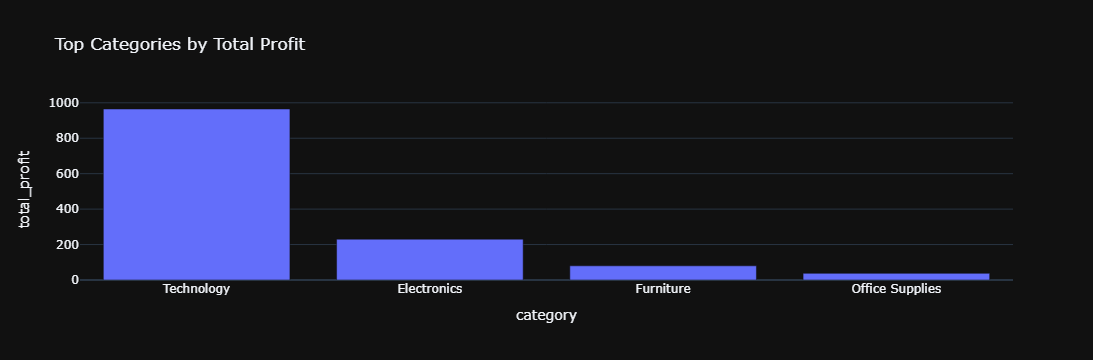

In [47]:
# Cell 7: Render markdown report, execute SQL dataframe & plot chart
import re
import json
import plotly.express as px
from IPython.display import Markdown, display

report_text = str(result)

# 1. Display Markdown Report
display(Markdown("## 📑 DataCrew Executive Report"))
display(Markdown(report_text))

# 2. Extract SQL & Show Result Table
sql_match = re.search(r"```sql\s*(.*?)\s*```", report_text, re.DOTALL | re.IGNORECASE)
if sql_match:
    executed_sql = sql_match.group(1).strip()
    print("\n🦆 Executed SQL Query:\n", executed_sql)
    result_df = con.execute(executed_sql).df()
    print("\n📊 Result DataFrame:")
    display(result_df)

# 3. Extract Chart Spec & Render Interactive Plotly Chart
spec_match = re.search(r"```(?:chart_spec|json)\s*(\{.*?\})\s*```", report_text, re.DOTALL | re.IGNORECASE)
if spec_match and 'result_df' in locals() and not result_df.empty:
    try:
        spec = json.loads(spec_match.group(1).strip())
        x = spec.get("x_col", result_df.columns[0])
        y = spec.get("y_col", result_df.columns[1] if len(result_df.columns) > 1 else x)
        title = spec.get("title", "Data Visualization")
        
        fig = px.bar(result_df, x=x, y=y, title=title, template="plotly_dark")
        fig.show()
    except Exception as e:
        print(f"Chart render fallback: {e}")
        # Simple fallback chart
        fig = px.bar(result_df, x=result_df.columns[0], y=result_df.columns[1], template="plotly_dark")
        fig.show()